<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>99221 למידה מרובת סוכנים</p>
<p>מטלה 1</p>
<p>שם: נדב פיירמן שטרן</p>
<p>תעודת זהות: 207018250</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבוא:</p>
<ul>
<li>מטרת המטלה — מימוש אלגוריתם Independent Q-Learning (IQL), שבו כל סוכן לומד את פונקציית ה-Q שלו באופן עצמאי באמצעות עדכוני Q-Learning, ללא כל מודל של הסוכן השני</li>
<li>הסביבה — משחק המטריצה "דילמת האסיר" (Prisoners' Dilemma) בגרסה חד-פעמית (non-repeated): הסוכנים משחקים סיבוב יחיד ומקבלים תגמול לפי צירוף הפעולות של שניהם</li>
<li>המשחק חסר מצב (stateless) — התצפית שהסוכנים מקבלים היא תמיד הקבוע 0, ולכן טבלת ה-Q של כל סוכן מכילה בפועל ערך אחד לכל פעולה</li>
<li>מה מממשים — הפונקציה act (בחירת פעולה epsilon-greedy) והפונקציה learn (עדכון ערכי ה-Q מהניסיון), וכן ניתן לשנות את תזמון האפסילון ב-schedule_hyperparameters</li>
<li>מהלך המטלה — אימון שני סוכני IQL לאורך 20,000 אפיזודות, הערכה תקופתית של הביצועים, והצגת ערכי ה-Q הנלמדים וגרפי ההתכנסות שלהם</li>
<li>הרחבות מעבר לנדרש — הערכה חמדנית סופית (epsilon = 0) המדגימה את שיווי המשקל במדויק, והשוואה בין שלושה תזמוני חקירה: ליניארי, אקספוננציאלי וקבוע</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיבור ל-Google Drive:</p>
<ul>
<li>עיגון Drive לקריאת קבצי ה-py של המטלה (iql, matrix_game, utils, train_iql, schedule_experiment)</li>
</ul>
</div>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרת נתיבים:</p>
<ul>
<li>יבוא ספריות
  <ul>
    <li>os — קריאת תוכן התיקייה ב-Google Drive לאימות נתיב קבצי הפרויקט</li>
    <li>sys — הוספת נתיב קבצי ה-py של הפרויקט ל-sys.path, לצורך ייבוא המודולים מ-Drive</li>
  </ul></li>
<li>נתיב תיקיית קבצי ה-py של המטלה</li>
<li>הוספת הנתיב ל-sys.path לצורך ייבוא המודולים</li>
</ul>
</div>

In [2]:
import os
import sys

PY_PATH = '/content/drive/MyDrive/לימודים/תואר שני/שנה א/סמסטר קיץ/למידה מרובת סוכנים/מטלות/מטלה 1'

print('PY_PATH:', os.listdir(PY_PATH))

if PY_PATH not in sys.path:
    sys.path.insert(0, PY_PATH)

PY_PATH: ['requirements.txt', 'Assignment_1.pdf', 'train_iql.py', 'matrix_game.py', 'iql.py', '__pycache__', 'utils.py', 'schedule_experiment.py', 'Multi_Agent_Reinforcement_Learning_HW1.ipynb']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התקנת הספריות הנדרשות:</p>
<ul>
<li>מתקינים gymnasium ו-matplotlib; NumPy נשאר בגרסת ברירת המחדל של Colab, ללא כפיית גרסה - ל-Colab כבר יש חבילות מותקנות מראש (כמו jax, opencv, shap) שדורשות NumPy 2.x, ונעילה לגרסה ישנה יותר הייתה מתנגשת איתן</li>
<li>האקראיות בתרגיל (ב-act וב-schedule) מבוססת על מודול random של פייתון ולא על NumPy, כך שגרסת NumPy אינה משפיעה על התוצאות</li>
</ul>
</div>

In [3]:
!pip install -q gymnasium matplotlib

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא הספריות:</p>
<ul>
<li>collections.defaultdict — מבנה הנתונים של טבלאות ה-Q; מחזיר ערך ברירת מחדל 0 לכל צירוף (תצפית, פעולה) שטרם נראה</li>
<li>copy — שכפול עמוק של טבלאות ה-Q בכל נקודת הערכה, לצורך גרף ההתכנסות</li>
<li>random — בחירות אקראיות: החקירה ב-epsilon-greedy ושבירת שוויון בין פעולות בעלות אותו ערך</li>
<li>typing (List, DefaultDict) — רמזי טיפוסים לחתימות הפונקציות</li>
<li>gymnasium (Space, flatdim) — הגדרת מרחבי הפעולה וקריאת מספר הפעולות של כל סוכן</li>
<li>numpy — וקטורי תגמולים, ממוצעים וסטיות תקן בהערכה</li>
<li>matplotlib — ויזואליזציה; נקבע סגנון ggplot אחיד לכל המחברת</li>
</ul>
<p>בנוסף, מודפסות גרסאות Gymnasium ו-NumPy לאימות הסביבה.</p>
</div>

In [4]:
from collections import defaultdict
import copy
import random
from typing import DefaultDict, List

import gymnasium as gym
from gymnasium.spaces import Space
from gymnasium.spaces.utils import flatdim
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('ggplot')

print(f'Gymnasium : {gym.__version__}')
print(f'NumPy     : {np.__version__}')

Gymnasium : 1.3.0
NumPy     : 2.0.2


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת חמשת מודולי הקוד וייבוא הפונקציות שבשימוש במחברת. reload מבטיח שעריכות בקבצי ה-PY ייטענו מחדש.</p>
<ul>
<li>matrix_game — סביבת המשחק
  <ul>
    <li>MatrixGame — סביבת gym כללית למשחק מטריצה
      <ul>
        <li>init — מקבל מטריצת תגמולים (n_actions_1, n_actions_2, 2) ואורך אפיזודה, ומגדיר את מרחבי התצפית והפעולה</li>
        <li>reset — מאפס את מונה הצעדים ומחזיר [0, 0]; המשחק חסר מצב, כך שהתצפית תמיד קבועה</li>
        <li>step — שולף את זוג התגמולים מהמטריצה לפי פעולות שני הסוכנים, ומסמן done לאחר ep_length צעדים (אצלנו צעד יחיד)</li>
        <li>render — מדפיס את מספר הצעד והפעולות האחרונות, לצורכי בדיקה</li>
      </ul></li>
    <li>create_pd_game — בניית דילמת האסיר
      <ul>
        <li>פעולה 0 = שיתוף פעולה (Cooperate), פעולה 1 = בגידה (Defect)</li>
        <li>מטריצת התגמולים: שיתוף הדדי (3,3); משתף מול בוגד (0,5); בוגד מול משתף (5,0); בגידה הדדית (1,1)</li>
        <li>מבנה הדילמה — בגידה היא אסטרטגיה שולטת לכל סוכן, אך בגידה הדדית (1,1) גרועה לשניהם משיתוף הדדי (3,3)</li>
      </ul></li>
  </ul></li>
<li>iql — סוכני Independent Q-Learning
  <ul>
    <li>IQL — טבלת Q נפרדת לכל סוכן
      <ul>
        <li>init — מאתחל טבלת Q לכל סוכן (defaultdict, ערך התחלתי 0) ושומר את היפר-פרמטרי הלמידה; מפתח הגישה הוא str((obs, action))</li>
        <li>act — epsilon-greedy: בהסתברות epsilon פעולה אקראית (חקירה), אחרת ה-argmax של הטבלה (ניצול), עם שבירת שוויון אקראית — קריטי בתחילת האימון כשכל הערכים 0</li>
        <li>learn — עדכון Q-Learning עצמאי: היעד r + gamma·maxQ(o',a') (או r בלבד כש-done), ועדכון Q(o,a) += lr·(target − Q(o,a)); במשחק החד-פעמי done תמיד True, כך שהיעד הוא התגמול המיידי בלבד</li>
        <li>update — alias ל-learn, בהתאם לניסוח "update" שמופיע בהנחיות המטלה; לא נקרא בפועל בשום תא במחברת</li>
        <li>schedule_hyperparameters — דעיכה ליניארית של epsilon מ-1.0 ל-0.01 לאורך 80% מהאימון; בסעיף ההרחבה מושווים אליה שני תזמונים חלופיים</li>
      </ul></li>
  </ul></li>
<li>utils — קבועים וויזואליזציה
  <ul>
    <li>קבועי גודל התרשימים — משותפים לכל הגרפים
      <ul>
        <li>FIG_WIDTH — רוחב בסיסי (באינץ') של כל תת-גרף</li>
        <li>FIG_HEIGHT — גובה בסיסי (באינץ') של כל תת-גרף</li>
        <li>FIG_ALPHA — שקיפות רצועת סטיית התקן סביב קווי הממוצע</li>
        <li>FIG_WSPACE — מרווח אופקי בין תתי-הגרפים</li>
        <li>FIG_HSPACE — מרווח אנכי בין תתי-הגרפים</li>
      </ul></li>
    <li>visualise_q_tables — מדפיסה לכל סוכן את Q(Cooperate) ו-Q(Defect)</li>
    <li>visualise_evaluation_returns — טבלת התשואות בכל נקודת הערכה, ואחריה גרף התשואה הממוצעת עם רצועת סטיית תקן</li>
    <li>visualise_q_convergence — טבלת ערכי ה-Q של שני הסוכנים, ואחריה רשת 2x2 של ההתכנסות מול התקרה התיאורטית מהמטריצה</li>
  </ul></li>
<li>train_iql — היפר-פרמטרים, אימון והערכה
  <ul>
    <li>CONFIG — היפר-פרמטרים של האימון
      <ul>
        <li>seed = 0 — זרע אקראיות לשחזור מלא</li>
        <li>gamma = 0.99 — מקדם היוון; חסר השפעה במשחק חד-צעדי, נשמר לכלליות המימוש</li>
        <li>total_eps = 20000 — מספר אפיזודות האימון</li>
        <li>ep_length = 1 — צעד יחיד בכל אפיזודה</li>
        <li>eval_freq = 400 — תדירות ההערכה</li>
        <li>lr = 0.05 — קצב הלמידה</li>
        <li>init_epsilon = 0.9 — אתחול פורמלי בלבד; נדרס ל-1.0 כבר ב-t=0 על ידי schedule_hyperparameters</li>
        <li>eval_epsilon = 0.05 — אפסילון קבוע וקטן בהערכה (כמעט חמדנית)</li>
      </ul></li>
    <li>iql_eval — יוצרת סוכני IQL עם deepcopy של טבלאות ה-Q ואפסילון קבוע 0.05, מריצה 500 אפיזודות הערכה ומחזירה ממוצע וסטיית תקן לכל סוכן</li>
    <li>train — לולאת האימון: בכל אפיזודה מתוזמן epsilon, נבחרת פעולה ב-act ומתבצע עדכון ב-learn; בכל נקודת הערכה נשמרים התוצאות וטבלאות ה-Q (מודפסת רק כל הערכה עשירית)</li>
  </ul></li>
<li>schedule_experiment — הרחבת השוואת תזמוני חקירה
  <ul>
    <li>ScheduledIQL — יורשת מ-IQL ומחליפה רק את schedule_hyperparameters; תומכת בתזמון ליניארי, אקספוננציאלי וקבוע</li>
    <li>train_schedule — לולאת אימון ברוח train, עם מעקב נוסף אחר מסלול epsilon לאורך האפיזודות</li>
    <li>visualise_schedule_comparison — טבלת ערכי ה-Q של שלושת התזמונים, ואחריה מסלול האפסילון ברוחב מלא ומתחתיו Q(Defect) ו-Q(Cooperate)</li>
  </ul></li>
</ul>
</div>

In [5]:
import importlib
import matrix_game, iql, utils, train_iql, schedule_experiment

importlib.reload(matrix_game)
importlib.reload(iql)
importlib.reload(utils)
importlib.reload(train_iql)
importlib.reload(schedule_experiment)

from matrix_game import MatrixGame, create_pd_game
from iql import IQL
from utils import (FIG_WIDTH, FIG_HEIGHT, FIG_ALPHA, FIG_WSPACE, FIG_HSPACE,
                   visualise_q_tables, visualise_evaluation_returns, visualise_q_convergence)
from train_iql import CONFIG, iql_eval, train
from schedule_experiment import (SCHEDULES, SCHEDULE_LABELS, ScheduledIQL, train_schedule,
                                 visualise_schedule_comparison)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שפיות לסביבה — משחקים את ארבעת צירופי הפעולות האפשריים ומוודאים שהתגמולים, התצפיות ודגל הסיום תואמים את הגדרת דילמת האסיר.</p>
</div>

In [6]:
env = create_pd_game()
action_names = {0: 'Cooperate', 1: 'Defect'}

for a1 in range(2):
    for a2 in range(2):
        env.reset()
        obss, rewards, done, _, _ = env.step([a1, a2])
        print(f'{action_names[a1]:<9} vs {action_names[a2]:<9} -> '
              f'rewards {tuple(int(r) for r in rewards)}, next obs {obss}, done={done}')

Cooperate vs Cooperate -> rewards (3, 3), next obs [0, 0], done=True
Cooperate vs Defect    -> rewards (0, 5), next obs [0, 0], done=True
Defect    vs Cooperate -> rewards (5, 0), next obs [0, 0], done=True
Defect    vs Defect    -> rewards (1, 1), next obs [0, 0], done=True


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הרצת האימון — 20,000 אפיזודות עם הערכה כל 400 אפיזודות. כדי לשמור על מסמך קריא מודפסת רק כל הערכה עשירית (אפיזודות 400, 4,400, 8,400, 12,400 ו-16,400): התשואה הממוצעת וסטיית התקן של כל סוכן על פני 500 אפיזודות הערכה. מלוא 49 נקודות ההערכה נשמרות ומוצגות בגרפים בהמשך.</p>
</div>

In [7]:
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

env = create_pd_game()
evaluation_return_means, evaluation_return_stds, eval_q_tables, q_tables = train(env, CONFIG)

Evaluation 1 (episode 400):
EVALUATION RETURNS:
	Agent 1: 1.03 ± 0.54
	Agent 2: 1.13 ± 0.76
Evaluation 11 (episode 4400):
EVALUATION RETURNS:
	Agent 1: 1.11 ± 0.74
	Agent 2: 1.05 ± 0.62
Evaluation 21 (episode 8400):
EVALUATION RETURNS:
	Agent 1: 1.04 ± 0.56
	Agent 2: 1.11 ± 0.72
Evaluation 31 (episode 12400):
EVALUATION RETURNS:
	Agent 1: 1.07 ± 0.67
	Agent 2: 1.13 ± 0.79
Evaluation 41 (episode 16400):
EVALUATION RETURNS:
	Agent 1: 1.10 ± 0.71
	Agent 2: 1.07 ± 0.65


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הצגת טבלאות ה-Q הסופיות — ערך ה-Q של כל פעולה עבור כל סוכן. הציפייה: ערך גבוה לבגידה וערך נמוך לשיתוף פעולה.</p>
</div>

In [8]:
visualise_q_tables(q_tables)

Q-table for Agent 1:
Q(Cooperate) = 0.05
Q(Defect) = 1.00

Q-table for Agent 2:
Q(Cooperate) = 0.05
Q(Defect) = 1.02



<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח טבלאות ה-Q:</p>
<ul>
<li>לשני הסוכנים ערך הבגידה התכנס לסביבות 1 — Q(Defect) = 1.00 לסוכן 1 ו-Q(Defect) = 1.02 לסוכן 2 — בעוד ערך שיתוף הפעולה נמוך וקרוב ל-0 (Q(Cooperate) = 0.05 לשניהם)</li>
<li>הערכים משקפים את התגמול הצפוי של כל פעולה כנגד יריב שכמעט תמיד בוגד: בגידה מניבה 1 (ולעיתים נדירות 5, כשהיריב חוקר), ושיתוף פעולה מניב 0 (ולעיתים נדירות 3) — ולכן שני הערכים מעט מעל התגמול הנקי של בגידה או שיתוף הדדיים</li>
<li>מכיוון שהמשחק חסר מצב, כל טבלה מכילה בפועל שני ערכים בלבד — אחד לכל פעולה — והם מסכמים את כל מה שהסוכן למד</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערכה סופית והערכה חמדנית — שתי הערכות משלימות על טבלאות ה-Q הסופיות:</p>
<ul>
<li>הערכה סופית עם eval_epsilon = 0.05 — נקודת הערכה נוספת לאחר סיום מלוא 20,000 האפיזודות (ההערכה התקופתית האחרונה בתוך הלולאה מתבצעת כבר באפיזודה 19,600)</li>
<li>הערכה חמדנית לחלוטין עם epsilon = 0 — כל סוכן בוחר תמיד את פעולת ה-argmax שלו ללא רעש חקירה; זו המדיניות הנלמדת "הנקייה"</li>
</ul>
</div>

In [9]:
print("Final evaluation (epsilon = 0.05):")
final_mean, final_std = iql_eval(env, CONFIG, q_tables)

greedy_config = dict(CONFIG, eval_epsilon=0.0)
print("\nGreedy evaluation (epsilon = 0):")
greedy_mean, greedy_std = iql_eval(env, greedy_config, q_tables)

Final evaluation (epsilon = 0.05):
EVALUATION RETURNS:
	Agent 1: 1.05 ± 0.59
	Agent 2: 1.11 ± 0.72

Greedy evaluation (epsilon = 0):
EVALUATION RETURNS:
	Agent 1: 1.00 ± 0.00
	Agent 2: 1.00 ± 0.00


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח ההערכות המשלימות:</p>
<ul>
<li>ההערכה הסופית עם epsilon = 0.05 (סוכן 1: 1.05 ± 0.59, סוכן 2: 1.11 ± 0.72) עקבית עם 49 נקודות ההערכה שלאורך האימון — הלמידה התייצבה הרבה לפני האפיזודה האחרונה</li>
<li>ההערכה החמדנית מחזירה בדיוק 1.00 ± 0.00 לשני הסוכנים: ללא חקירה שני הסוכנים משחקים (Defect, Defect) בכל אפיזודה — תוצאת שיווי המשקל של דילמת האסיר, באופן דטרמיניסטי לחלוטין</li>
<li>ההשוואה בין השתיים מבודדת את מקור הרעש: כל התשואה שמעל 1 וכל סטיית התקן בהערכות הרגילות נובעות אך ורק מהחקירה השיורית (eval_epsilon = 0.05), ולא מחוסר יציבות של המדיניות הנלמדת</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרף תשואות ההערכה — התשואה הממוצעת של כל סוכן בכל אחת מ-49 נקודות ההערכה לאורך האימון; הרצועה סביב הקו היא סטיית התקן על פני 500 אפיזודות ההערכה.</p>
</div>

Evaluation returns (49 evaluations, every 4th shown)
  Eval   A1 mean   A1 std   A2 mean   A2 std
     1     1.028    0.540     1.128    0.759
     5     1.046    0.558     1.086    0.653
     9     1.096    0.703     1.066    0.640
    13     1.072    0.635     1.072    0.635
    17     1.082    0.635     1.052    0.563
    21     1.040    0.564     1.110    0.720
    25     1.126    0.760     1.036    0.568
    29     1.060    0.580     1.060    0.580
    33     1.104    0.725     1.064    0.642
    37     1.048    0.567     1.098    0.681
    41     1.104    0.714     1.074    0.652
    45     1.142    0.806     1.052    0.630
    49     1.106    0.703     1.046    0.569



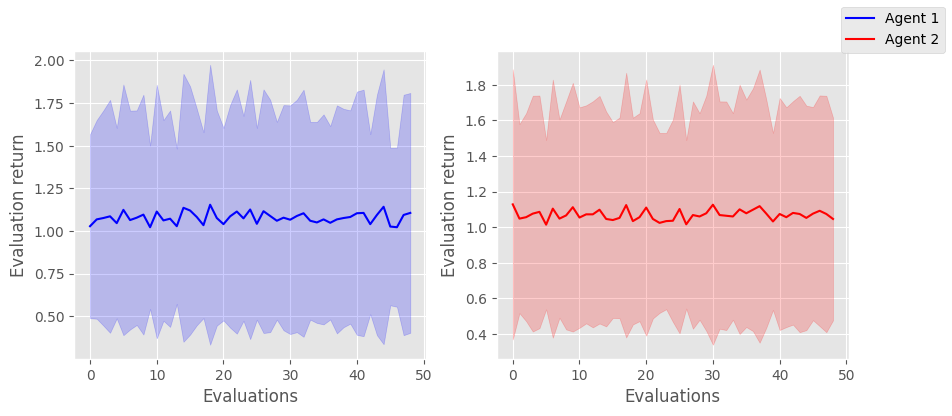

In [10]:
visualise_evaluation_returns(evaluation_return_means, evaluation_return_stds)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרף התשואות:</p>
<ul>
<li>כבר בנקודת ההערכה הראשונה (אחרי 400 אפיזודות בלבד) התשואה הממוצעת עומדת על כ-1.0 עד 1.1 לכל סוכן — הפעולה החמדנית של שני הסוכנים היא בגידה כמעט מההתחלה, עוד כשהאפסילון באימון גבוה</li>
<li>העקומות נותרות שטוחות סביב 1.05 עד 1.10 לאורך כל האימון (בנקודת ההערכה האחרונה: 1.11 לסוכן 1 ו-1.05 לסוכן 2) — תגמול שיווי המשקל של בגידה הדדית, הרחק מהתשואה של שיתוף הדדי (3)</li>
<li>הערכים מעט מעל 1 בגלל eval_epsilon = 0.05: לעיתים נדירות אחד הסוכנים משתף פעולה בהערכה, והיריב הבוגד גורף אז תגמול של 5</li>
<li>סטיית התקן (כ-0.5 עד 0.8) נובעת מאותו רעש של המדיניות הכמעט-חמדנית בהערכה, ואינה מעידה על חוסר יציבות בלמידה עצמה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרף התכנסות ערכי ה-Q — לכל סוכן ולכל פעולה מוצג ערך ה-Q לאורך נקודות ההערכה, מול קו מקווקק של התגמול המקסימלי האפשרי לאותה פעולה (המקסימום על פני פעולות היריב במטריצת התגמולים): 3 עבור שיתוף פעולה ו-5 עבור בגידה.</p>
</div>

Q-values (every 8th evaluation)
  Eval   A1 Q(C)   A1 Q(D)   A2 Q(C)   A2 Q(D)
     1     1.162     2.719     1.286     2.876
     9     0.778     2.382     0.792     2.513
    17     0.893     2.475     0.735     1.960
    25     0.506     1.924     0.386     1.583
    33     0.146     1.295     0.125     1.228
    41     0.145     1.000     0.115     1.000
    49     0.058     1.017     0.062     1.000



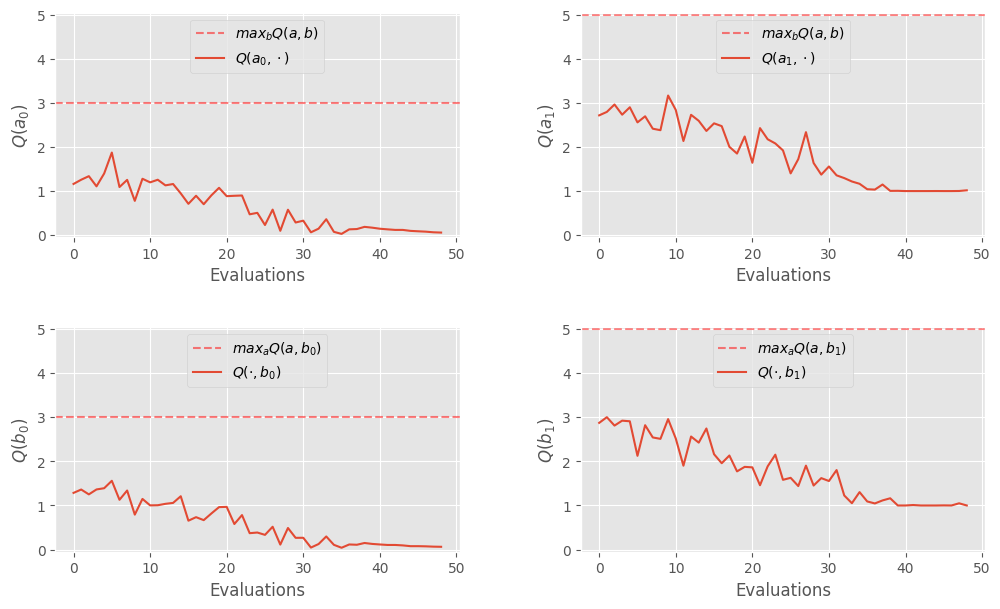

In [11]:
visualise_q_convergence(eval_q_tables, env)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרף ההתכנסות:</p>
<ul>
<li>ערכי הבגידה (Q(a_1) ו-Q(b_1)) מתחילים סביב 2.7 עד 2.9 ואף מטפסים תחילה לכיוון 3 — התוחלת של בגידה מול יריב כמעט אקראי (0.5·5 + 0.5·1) — עד שיא של 3.17 לסוכן 1 (נקודת הערכה 10) ו-3.01 לסוכן 2 (נקודת הערכה 2); רק משם הם דועכים בהדרגה אל 1 ככל שהיריב לומד בעצמו לבגוד</li>
<li>ערכי שיתוף הפעולה (Q(a_0) ו-Q(b_0)) מתחילים סביב 1.2 עד 1.3 מאותה סיבה, ואף עולים תחילה לשיא של כ-1.87 לסוכן 1 ו-1.56 לסוכן 2 (נקודת הערכה 6), ורק משם דועכים אל כמעט 0 — בסוף האימון היריב כמעט אינו משתף פעולה, ולכן שיתוף מניב כמעט תמיד 0</li>
<li>הקווים המקווקווים (5 לבגידה, 3 לשיתוף) הם התקרה התאורטית של כל פעולה; הפער בין הערך הנלמד לתקרה משקף את התנהגות היריב בפועל, לא חוסר למידה</li>
<li>הדינמיקה הזו ממחישה את אי-הסטציונריות של MARL: מנקודת מבטו של כל סוכן היריב הוא חלק מהסביבה, ולכן ערכה של אותה פעולה עצמה נודד לאורך הזמן כשהיריב משנה את מדיניותו</li>
<li>שני הסוכנים מציגים עקומות כמעט זהות — כצפוי במשחק סימטרי עם אותם היפר-פרמטרים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הרחבה: השוואת תזמוני חקירה (epsilon schedules)</p>
<ul>
<li>הנחיות המטלה מזמינות לשנות את schedule_hyperparameters; כאן מושווים שלושה תזמונים תחת אותם היפר-פרמטרים ואותו seed (0), כך שההבדל היחיד בין הריצות הוא מסלול האפסילון</li>
<li>ליניארי (ברירת המחדל) — דעיכה מ-1.0 ל-0.01 לאורך 80 אחוז מצעדי האימון: epsilon(t) = 1 − 0.99·min(1, t/0.8T)</li>
<li>אקספוננציאלי — epsilon(t) = max(0.01, 0.01^(t/0.8T)): מתחיל אף הוא ב-1.0 ומגיע לרצפה 0.01 באותה נקודה, אך צונח מהר בהרבה בתחילת הדרך (כבר ב-40 אחוז מהאימון epsilon = 0.1)</li>
<li>קבוע — epsilon = 0.1 לכל אורך האימון: חקירה שיורית קבועה ללא דעיכה</li>
<li>ScheduledIQL ו-train_schedule מיובאות מ-schedule_experiment; כאן רק מריצים את שלושת התזמונים ואוספים את התוצאות</li>
</ul>
</div>

In [12]:
schedule_results = {s: train_schedule(env, CONFIG, s) for s in SCHEDULES}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום מספרי לכל תזמון — ערכי ה-Q הסופיים של שני הסוכנים, תוצאת הערכה חמדנית (epsilon = 0) על הטבלאות הסופיות, ותוצאת נקודת ההערכה האחרונה (epsilon = 0.05).</p>
</div>

In [13]:
for s in SCHEDULES:
    res = schedule_results[s]
    print(f"--- {SCHEDULE_LABELS[s]} ---")
    for i in range(env.n_agents):
        q_c = res["q_tables"][i][str((0, 0))]
        q_d = res["q_tables"][i][str((0, 1))]
        print(f"Agent {i + 1}: Q(Cooperate) = {q_c:.2f} | Q(Defect) = {q_d:.2f}")
    greedy_mean, _ = iql_eval(env, dict(CONFIG, eval_epsilon=0.0), res["q_tables"], output=False)
    last_mean = res["eval_means"][-1]
    print(f"Greedy evaluation: ({greedy_mean[0]:.2f}, {greedy_mean[1]:.2f}) | "
          f"Last evaluation (eps=0.05): ({last_mean[0]:.2f}, {last_mean[1]:.2f})")
    print()

--- Linear decay ---
Agent 1: Q(Cooperate) = 0.05 | Q(Defect) = 1.00
Agent 2: Q(Cooperate) = 0.05 | Q(Defect) = 1.02
Greedy evaluation: (1.00, 1.00) | Last evaluation (eps=0.05): (1.11, 1.05)

--- Exponential decay ---
Agent 1: Q(Cooperate) = 0.00 | Q(Defect) = 1.00
Agent 2: Q(Cooperate) = 0.01 | Q(Defect) = 1.02
Greedy evaluation: (1.00, 1.00) | Last evaluation (eps=0.05): (1.11, 1.05)

--- Constant (0.1) ---
Agent 1: Q(Cooperate) = 0.13 | Q(Defect) = 1.38
Agent 2: Q(Cooperate) = 0.12 | Q(Defect) = 1.07
Greedy evaluation: (1.00, 1.00) | Last evaluation (eps=0.05): (1.11, 1.05)



<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרפים משווים — למעלה מסלול האפסילון של כל תזמון לאורך האפיזודות; למטה התכנסות ערכי ה-Q של סוכן 1 (Q(Defect) משמאל, Q(Cooperate) מימין) לאורך נקודות ההערכה תחת כל תזמון, עם קווים מקווקווים בערכי הבגידה ההדדית (1 ו-0). סוכן 2 מציג עקומות כמעט זהות בשל סימטריית המשחק.</p>
</div>

Agent 1 Q-values per schedule (every 8th evaluation)
  Eval   lin Q(D)   exp Q(D)   con Q(D)   lin Q(C)   exp Q(C)   con Q(C)
     1      2.719      2.550      1.319      1.162      1.069      0.103
     9      2.382      1.566      1.123      0.778      0.422      0.004
    17      2.475      1.229      1.078      0.893      0.380      0.188
    25      1.924      1.060      1.357      0.506      0.010      0.268
    33      1.295      1.002      1.214      0.146      0.060      0.069
    41      1.000      1.000      1.043      0.145      0.014      0.071
    49      1.017      1.017      1.274      0.058      0.005      0.034



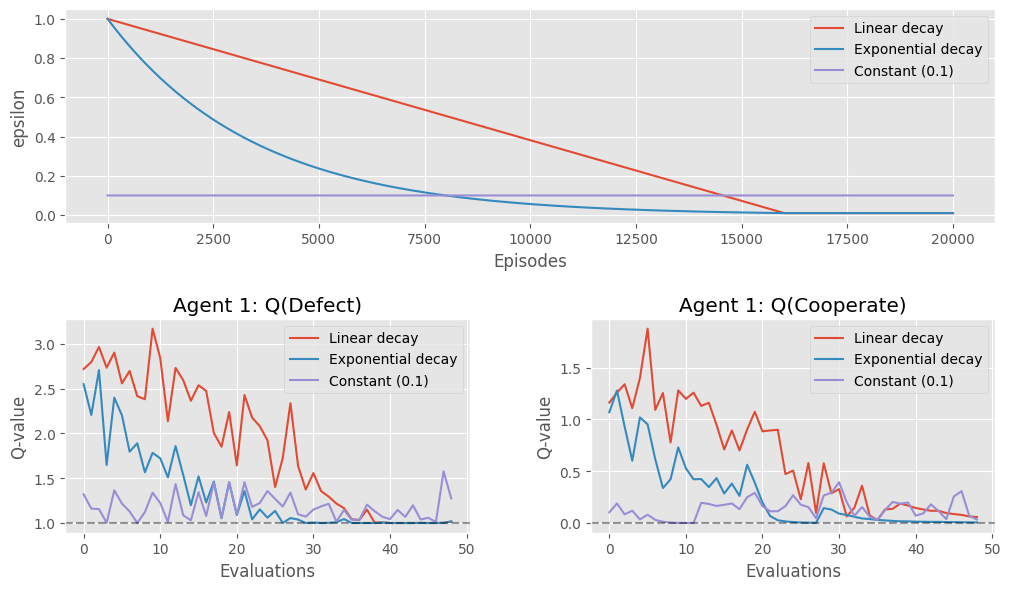

In [14]:
visualise_schedule_comparison(schedule_results)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח השוואת התזמונים:</p>
<ul>
<li>היעד זהה בשלושת התזמונים — הערכה חמדנית מחזירה בדיוק (1.00, 1.00) בכולם, וטבלאות ה-Q מדרגות בכולם את הבגידה מעל שיתוף הפעולה: בגידה הדדית היא נקודת המשיכה של הדינמיקה, ובחירת התזמון אינה משנה את שיווי המשקל שאליו מתכנסים אלא רק את הדרך אליו</li>
<li>ליניארי — משחזר אחד לאחד את הריצה הראשית (אותו seed ואותו תזמון): Q(Defect) מטפס עד 3.17 בשיא ודועך אל 1.00 ו-1.02, ו-Q(Cooperate) מסיים ב-0.05 לשני הסוכנים</li>
<li>אקספוננציאלי — האפסילון צונח מוקדם והיריב מתקבע על בגידה הרבה יותר מהר, ולכן ניפוח הערכים החולף קטן ומוקדם יותר: Q(Defect) מגיע בשיא רק ל-2.71 ו-2.75 ודועך מוקדם (אצל סוכן 2 הוא כבר 1.02 בנקודת הערכה 20, לעומת 1.88 בליניארי), ו-Q(Cooperate) קורס עד 0.00 ו-0.01 משום ששיתוף כמעט אינו משוחק בהמשך האימון; ערכי הסיום של הבגידה — 1.00 ו-1.02 — זהים כמעט לליניארי</li>
<li>קבוע (epsilon = 0.1) — החקירה השיורית של היריב אינה דועכת לעולם, ולכן ערכי ה-Q אינם מתכנסים לערכי הבגידה ההדדית אלא מתנודדים סביב התוחלת מול יריב שבוגד בהסתברות 0.95: Q(Defect) סביב 1.2 = 0.95·1 + 0.05·5 (בסוף האימון: 1.38 ו-1.07, עם תנודות עד 1.58 לאורך הדרך) ו-Q(Cooperate) סביב 0.15 = 0.05·3 (בסוף: 0.13 ו-0.12)</li>
<li>התשואות בנקודת ההערכה האחרונה דומות בכל התזמונים (סביב 1.05 עד 1.11) — עדות נוספת לכך שבסוף האימון שלושתם משחקים למעשה את אותה מדיניות</li>
<li>הסתייגות מתודולוגית — ההשוואה מבוצעת על seed יחיד ולכן איכותית באופייה; להסקה כמותית ראוי היה למצע על פני מספר seeds</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום ומסקנות:</p>
<ul>
<li>מימשנו את act — בחירה epsilon-greedy עם שבירת שוויון אקראית — ואת learn — עדכון Q-Learning עצמאי לכל סוכן — והרצנו את לולאת האימון וההערכה המלאה של המטלה</li>
<li>שני סוכני ה-IQL התכנסו לבגידה הדדית, שיווי המשקל היחיד של דילמת האסיר החד-פעמית, עם תשואה של כ-1 לכל סוכן ועם Q(Defect) גבוה מובהק מ-Q(Cooperate)</li>
<li>התוצאה ממחישה נקודה מרכזית בלמידה מרובת סוכנים: לומדים עצמאיים רציונליים מתכנסים לשיווי המשקל גם כשהוא נחות פארטו — שיתוף הדדי (3,3) היה מיטיב עם שניהם, אך אינו יציב כשכל סוכן ממקסם רק לעצמו</li>
<li>האתגר שנחשף כאן — יריב שהוא חלק לא-סטציונרי מהסביבה — הוא בדיוק המוטיבציה לאלגוריתמים מרובי הסוכנים שנראה בהמשך הקורס ובמטלות הבאות</li>
<li>הערכה חמדנית לחלוטין (epsilon = 0) על טבלאות ה-Q הסופיות מחזירה בדיוק (1, 1) בסטיית תקן אפס — המדיניות הנלמדת היא בגידה הדדית דטרמיניסטית, וכל התשואה העודפת וסטיית התקן בהערכות הרגילות נובעות מרעש החקירה בלבד</li>
<li>השוואת שלושה תזמוני חקירה (ליניארי, אקספוננציאלי וקבוע) מראה שהיעד זהה — כולם מתכנסים לבגידה הדדית ולהערכה חמדנית של (1, 1) — והתזמון קובע בעיקר את מהירות ההתקבעות על בגידה ואת גובה ערכי ה-Q כפונקציה של החקירה השיורית של היריב</li>
</ul>
</div>